VARIABLES RECONSTRUCTION — MULTI-SCENARIO
==========================================
Reconstructs physical variables (T_sim, GHI_sim, CR_sim) from
raw copula innovations for all 3 penetration scenarios.
Temperature scenarios are applied in the Revenue Index notebook.
 
Penetration scenarios (from df_penetration_scenarios.parquet):
  pen_current_trend  → 30% solar share by 2050
  pen_pniec          → 45% solar share by 2050  (PNIEC 2024)
  pen_entso_e        → 60% solar share by 2050  (ENTSO-E DE)
 
Steps covered here:
  Step 0  — Imports, paths, constants
  Step 1  — Load parameters and innovations
  Step 2  — Build simulation calendar + load all 3 penetration scenarios
             2.1  calendar
             2.2  load penetration scenarios from parquet
             2.3  clear-sky GHI by doy
             2.4  temperature seasonal mean (baseline trend only)
             2.5  solar Ȳ_t seasonal mean
             2.6  precompute μ_CR for each penetration scenario
             2.7  state vector initialisation
  Step 3  — Reconstruct T_sim(t)     [shared across all scenarios]
  Step 4  — Reconstruct GHI_sim(t)   [shared across all scenarios]
  Step 5  — Reconstruct CR_sim(t)    [one per penetration scenario]
  Step 6  — Save physical variables  [one parquet per penetration scenario]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import t as t_dist, norm
from statsmodels.tsa.arima.model import ARIMAResults
from pathlib import Path
import pickle
import json
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────────
data_modelled = Path("../../Data/Modelled")
data_sim      = Path("../../Data/Simulated")
data_cleaned  = Path("../../Data/Cleaned")
models_path   = Path("../../Code/Models")
copula_path   = Path("../../Code/Models/Copula")
output_path   = Path("../../Data/Simulated")
output_path.mkdir(parents=True, exist_ok=True)

In [3]:
# ── simulation constants ──────────────────────────────────────────────────────
START_DATE  = "2026-01-01"
END_DATE    = "2050-12-31"
G_STC       = 1000.0    # W/m²
PR          = 0.80
GAMMA       = -0.004    # /°C
L_FIXED     = 0.6       # CR logistic lower bound
CRISIS_FLAG = 0         # no crisis in forward simulation

In [4]:
# penetration scenario column names in df_penetration_scenarios.parquet
PEN_SCENARIOS = {
    "current_trend": "pen_current_trend",   # 30% by 2050
    "pniec":         "pen_pniec",           # 45% by 2050
    "entso_e":       "pen_entso_e",         # 60% by 2050
}
PEN_LABELS = {
    "current_trend": "Current Trend (30%)",
    "pniec":         "PNIEC 2024 (45%)",
    "entso_e":       "ENTSO-E DE (60%)",
}
 
print("── Step 0: Configuration ────────────────────────────────────────")
print(f"  Horizon      : {START_DATE} → {END_DATE}")
print(f"  G_STC        : {G_STC} W/m²   PR={PR}   γ={GAMMA}/°C")
print(f"  L_FIXED CR   : {L_FIXED}")
print(f"  Pen scenarios: {list(PEN_SCENARIOS.keys())}")
print(f"  data_sim     : {data_sim.resolve()}")

── Step 0: Configuration ────────────────────────────────────────
  Horizon      : 2026-01-01 → 2050-12-31
  G_STC        : 1000.0 W/m²   PR=0.8   γ=-0.004/°C
  L_FIXED CR   : 0.6
  Pen scenarios: ['current_trend', 'pniec', 'entso_e']
  data_sim     : C:\Users\LucasMonero\Documents\data projects\Master Thesis\Project\Data\Simulated


# STEP 1 — Load parameters and innovations

In [5]:

print(f"\n── Step 1: Load parameters and innovations ──────────────────────")

# ── 1.1 copula / marginal parameters ─────────────────────────────────────────
with open(copula_path / "copula_params.pkl", "rb") as f:
    copula_params = pickle.load(f)
nu_copula = int(copula_params["nu"])
print(f"  Copula       : t(ν={nu_copula})")

with open(copula_path / "marginal_params.pkl", "rb") as f:
    marginal_params = pickle.load(f)
sigma_kt   = float(marginal_params["sigma_kt"])
nu_temp    = float(marginal_params["nu_temp"])
scale_temp = float(marginal_params["scale_temp"])
sigma_temp = float(marginal_params["sigma_temp"])
print(f"  KT marginal  : Gaussian  σ={sigma_kt:.5f}")
print(f"  Temp marginal: t(ν={nu_temp:.2f})  scale={scale_temp:.5f}")

# ── 1.2 CR model parameters ───────────────────────────────────────────────────
with open(models_path / "Capture rate" / "cr_ar_params.pkl", "rb") as f:
    cr_params = pickle.load(f)

phi_s        = float(cr_params["phi_s"])
Phi_s        = float(cr_params["Phi_s"])
theta_q      = float(cr_params["theta_q"])
omega_g      = float(cr_params["garch_omega"])
alpha_g      = float(cr_params["garch_alpha"])
beta_g       = float(cr_params["garch_beta"])
nu_g         = float(cr_params["nu_g"])
eta_g        = float(cr_params["eta_g"])   # skewness parameter
L_FIXED_cr   = float(cr_params["L_FIXED"])
U_FIXED_cr   = float(cr_params["U_FIXED"])
k_fit        = float(cr_params["k"])
pen0_fit     = float(cr_params["pen_0"])
beta_fourier = np.array(cr_params["beta_fourier"])
N_HARMONICS  = int(cr_params["N_harmonics"])
beta_log     = float(cr_params["beta_log"])
beta_weekend = float(cr_params["beta_weekend"])

print(f"  CR SARIMA    : φ={phi_s:+.4f}  Φ={Phi_s:+.4f}  θ={theta_q:+.4f}")
print(f"  CR GARCH     : ω={omega_g:.6f}  α={alpha_g:.4f}  β={beta_g:.4f}")
print(f"  CR t(ν={nu_g:.2f}): unit-variance innovations")
print(f"  CR logistic  : L={L_FIXED_cr}  U={U_FIXED_cr:.4f}  "
      f"k={k_fit:.4f}  pen₀={pen0_fit:.4f}")

# ── 1.3 temperature model parameters ─────────────────────────────────────────
with open(models_path / "Temperature" / "temp_model_params.pkl", "rb") as f:
    temp_params = pickle.load(f)

ar_temp        = np.array(temp_params["ar_coeffs"])
trend_slope    = float(temp_params["trend_slope"])
fourier_mean   = float(temp_params["fourier_mean"])
trend_ref_year = float(temp_params["trend_ref_year"])
fourier_a      = list(temp_params["fourier_a"])
fourier_b      = list(temp_params["fourier_b"])
init_ar_resid  = np.array(temp_params["init_ar_resid"])

print(f"  Temp AR      : {ar_temp}  (order {len(ar_temp)})")
print(f"  Temp trend   : {trend_slope:+.5f}°C/year  ref={trend_ref_year:.0f}")
print(f"  Fourier mean : {fourier_mean:.4f}°C  harmonics={len(fourier_a)}")
print(f"  Temp init    : {init_ar_resid}")

# ── 1.4 KT / solar model parameters ──────────────────────────────────────────
arma_result = ARIMAResults.load(
    str(models_path / "GHI - KT" / "ghi_arma_result.pkl")
)
arma_phi   = arma_result.arparams
arma_theta = arma_result.maparams

with open(models_path / "GHI - KT" / "ghi_seasonal_coeffs.pkl", "rb") as f:
    a_seasonal = np.array(pickle.load(f))

with open(models_path / "GHI - KT" / "model_meta.json", "r") as f:
    meta = json.load(f)
alpha_kt = float(meta["logit_transform"]["alpha"])
beta_kt  = float(meta["logit_transform"]["beta"])

print(f"  KT ARMA(2,1) : AR={np.round(arma_phi,4)}  MA={np.round(arma_theta,4)}")
print(f"  KT seasonal  : a=[{a_seasonal[0]:.4f}, "
      f"{a_seasonal[1]:.4f}, {a_seasonal[2]:.4f}]")
print(f"  KT logit     : α={alpha_kt:.6f}  β={beta_kt:.6f}")

# ── 1.5 load raw copula innovations ──────────────────────────────────────────
print(f"\n  Loading mc_innovations.parquet...")
df_innov = pd.read_parquet(data_sim / "mc_innovations.parquet")
df_innov["date"] = pd.to_datetime(df_innov["date"])

N_SIM  = int(df_innov["sim_id"].nunique())
N_DAYS = int(df_innov.groupby("sim_id").size().iloc[0])
print(f"  Innovations  : {N_SIM} paths × {N_DAYS} days")
print(f"  Date range   : {df_innov['date'].min().date()} → "
      f"{df_innov['date'].max().date()}")

df_innov_sorted = df_innov.sort_values(["sim_id", "date"]).reset_index(drop=True)
eps_cr_raw   = df_innov_sorted["eps_cr"].values.reshape(N_SIM, N_DAYS)
eps_kt_raw   = df_innov_sorted["eps_kt"].values.reshape(N_SIM, N_DAYS)
eps_temp_raw = df_innov_sorted["eps_temp"].values.reshape(N_SIM, N_DAYS)
dates_sim    = np.sort(pd.to_datetime(df_innov_sorted["date"].unique()))
print(f"  Arrays shaped: (N_SIM={N_SIM}, N_DAYS={N_DAYS})")

# ── 1.6 load historical data for state initialisation ────────────────────────
print(f"\n  Loading historical modelled data...")

df_cr_hist = pd.read_parquet(data_modelled / "df_cr_modelled.parquet")
df_cr_hist["date"] = pd.to_datetime(df_cr_hist["date"])
df_cr_hist = df_cr_hist.sort_values("date").reset_index(drop=True)

df_solar_hist = pd.read_parquet(data_modelled / "df_solar_modelled.parquet")
df_solar_hist = df_solar_hist.reset_index()
df_solar_hist["date"] = pd.to_datetime(df_solar_hist["date"])
df_solar_hist = df_solar_hist.sort_values("date").reset_index(drop=True)

df_temp_hist = pd.read_parquet(data_modelled / "df_temperature_modeled.parquet")
df_temp_hist["date"] = pd.to_datetime(df_temp_hist["date"])
df_temp_hist = df_temp_hist.sort_values("date").reset_index(drop=True)

hist_n_days = len(df_solar_hist)

print(f"  CR hist      : {len(df_cr_hist)} rows  "
      f"{df_cr_hist['date'].max().date()}")
print(f"  Solar hist   : {hist_n_days} rows  "
      f"{df_solar_hist['date'].max().date()}")
print(f"  Temp hist    : {len(df_temp_hist)} rows  "
      f"{df_temp_hist['date'].max().date()}")
print(f"  hist_n_days  : {hist_n_days}  "
      f"(sim starts at absolute day {hist_n_days})")


── Step 1: Load parameters and innovations ──────────────────────
  Copula       : t(ν=31)
  KT marginal  : Gaussian  σ=2.33721
  Temp marginal: t(ν=8.02)  scale=0.86725
  CR SARIMA    : φ=+0.3168  Φ=+0.9094  θ=-0.6556
  CR GARCH     : ω=0.279081  α=0.0712  β=0.9170
  CR t(ν=4.23): unit-variance innovations
  CR logistic  : L=0.6  U=1.0805  k=1.9829  pen₀=1.4530
  Temp AR      : [ 1.04116906 -0.22838148]  (order 2)
  Temp trend   : +0.05851°C/year  ref=2005
  Fourier mean : 12.6925°C  harmonics=3
  Temp init    : [-0.35639875 -1.33804454]
  KT ARMA(2,1) : AR=[ 1.2977 -0.3397]  MA=[-0.8998]
  KT seasonal  : a=[-2.1033, 0.8836, 0.2350]
  KT logit     : α=-0.001000  β=0.911341

  Loading mc_innovations.parquet...
  Innovations  : 1000 paths × 9131 days
  Date range   : 2026-01-01 → 2050-12-31
  Arrays shaped: (N_SIM=1000, N_DAYS=9131)

  Loading historical modelled data...
  CR hist      : 7670 rows  2025-12-31
  Solar hist   : 7670 rows  2025-12-31
  Temp hist    : 7670 rows  2025-12-31

# STEP 2 — Build simulation calendar and load all penetration scenarios


In [6]:

print(f"\n── Step 2: Simulation calendar and penetration scenarios ─────────")
 
# ── 2.1 simulation calendar ───────────────────────────────────────────────────
dates_pd = pd.date_range(start=START_DATE, end=END_DATE, freq="D")
assert len(dates_pd) == N_DAYS, \
    f"Calendar {len(dates_pd)} ≠ innovations {N_DAYS}"
 
df_cal = pd.DataFrame({
    "date":         dates_pd,
    "year":         dates_pd.year,
    "month":        dates_pd.month,
    "doy":          dates_pd.dayofyear,
    "weekday":      dates_pd.weekday,
    "decimal_year": dates_pd.year + (dates_pd.dayofyear - 1) / 365.0,
    "t_year":       (dates_pd.dayofyear - 1) / 365.0,
    "is_saturday":  (dates_pd.weekday == 5).astype(int),
    "is_sunday":    (dates_pd.weekday == 6).astype(int),
})
 
t_abs_sim      = np.arange(hist_n_days, hist_n_days + N_DAYS)
df_cal["t_abs"] = t_abs_sim
 
print(f"  Calendar     : {len(df_cal)} days  ({START_DATE} → {END_DATE})")
print(f"  t_abs range  : [{t_abs_sim[0]}, {t_abs_sim[-1]}]")


── Step 2: Simulation calendar and penetration scenarios ─────────
  Calendar     : 9131 days  (2026-01-01 → 2050-12-31)
  t_abs range  : [7670, 16800]


In [7]:
# ── 2.2 load all 3 penetration scenarios from parquet ─────────────────────────
df_pen_scen = pd.read_parquet(data_cleaned / "df_penetration_scenarios.parquet")
df_pen_scen["date"] = pd.to_datetime(df_pen_scen["date"])
 
# align to simulation calendar
df_pen_aligned = df_pen_scen.set_index("date").reindex(dates_pd)
 
# store each scenario as a numpy array (N_DAYS,)
pen_arrays = {}
for scen_key, col_name in PEN_SCENARIOS.items():
    pen_arrays[scen_key] = df_pen_aligned[col_name].values
    pen_2026 = float(pen_arrays[scen_key][df_cal["year"] == 2026].mean())
    pen_2050 = float(pen_arrays[scen_key][df_cal["year"] == 2050].mean())
    share_2050 = pen_2050 * float(df_pen_scen["solar_share_" + col_name.replace("pen_","")].max()) \
                 if "solar_share_" + col_name.replace("pen_","") in df_pen_scen.columns \
                 else pen_2050 * 13.0
    print(f"  {PEN_LABELS[scen_key]:<25}: "
          f"pen(2026)={pen_2026:.3f}  pen(2050)={pen_2050:.3f}")
 
print(f"\n  Loaded {len(PEN_SCENARIOS)} penetration scenarios  "
      f"({len(df_pen_aligned)} days each)")

  Current Trend (30%)      : pen(2026)=1.022  pen(2050)=2.315
  PNIEC 2024 (45%)         : pen(2026)=1.030  pen(2050)=3.475
  ENTSO-E DE (60%)         : pen(2026)=1.036  pen(2050)=4.634

  Loaded 3 penetration scenarios  (9131 days each)


In [8]:
# ── 2.3 clear-sky GHI by day-of-year ─────────────────────────────────────────
ghi_cs_col = None
for c in ["GHI_cs", "GHI_cs_sum", "ghi_cs_sum", "GHI_clearsky"]:
    if c in df_solar_hist.columns:
        ghi_cs_col = c
        break
if ghi_cs_col is None and "ghi_cs_sum" in df_cr_hist.columns:
    ghi_cs_col = "ghi_cs_sum"
    df_solar_hist = df_solar_hist.merge(
        df_cr_hist[["date", "ghi_cs_sum"]], on="date", how="left"
    )
 
df_solar_hist["doy"] = df_solar_hist["date"].dt.dayofyear
ghi_cs_doy = df_solar_hist.groupby("doy")[ghi_cs_col].mean()
 
ghi_clearsky_sim = np.array([
    ghi_cs_doy.get(int(d), float(ghi_cs_doy.mean()))
    for d in df_cal["doy"].values
])
df_cal["ghi_clearsky"] = ghi_clearsky_sim
print(f"\n  Clear-sky GHI: [{ghi_clearsky_sim.min():.0f}, "
      f"{ghi_clearsky_sim.max():.0f}] Wh/m²  "
      f"mean={ghi_clearsky_sim.mean():.0f}")


  Clear-sky GHI: [1889, 8320] Wh/m²  mean=5203


In [9]:
# ── 2.4 temperature seasonal mean — BASELINE trend only ───────────────────────
# SSP temperature scenarios are applied in the Revenue Index notebook.
# Here we compute the baseline (historical trend) seasonal component only.
_doy_arr = df_cal["doy"].values.astype(float)
_dyr_arr = df_cal["decimal_year"].values

temp_seasonal_sim = (
    fourier_mean
    + np.sum(
        [
            fourier_a[i] * np.cos(2 * np.pi * (i + 1) * _doy_arr / 365)
            + fourier_b[i] * np.sin(2 * np.pi * (i + 1) * _doy_arr / 365)
            for i in range(len(fourier_a))
        ],
        axis=0,
    )
    + trend_slope * (_dyr_arr - trend_ref_year)
)
df_cal["temp_seasonal_baseline"] = temp_seasonal_sim

print(f"  Temp seasonal (baseline): "
      f"[{temp_seasonal_sim.min():.1f}, "
      f"{temp_seasonal_sim.max():.1f}]°C  "
      f"(+{trend_slope:.3f}°C/year)")

# annual sanity check
for yr in [2026, 2035, 2050]:
    m = df_cal["year"] == yr
    print(f"    {yr} mean trend: "
          f"{temp_seasonal_sim[m].mean():.2f}°C  "
          f"{'✓ plausible' if 10 < temp_seasonal_sim[m].mean() < 22 else '✗ check'}")

  Temp seasonal (baseline): [3.2, 26.2]°C  (+0.059°C/year)
    2026 mean trend: 13.95°C  ✓ plausible
    2035 mean trend: 14.48°C  ✓ plausible
    2050 mean trend: 15.35°C  ✓ plausible


In [10]:
# ── 2.5 solar Ȳ_t seasonal mean (absolute day index) ─────────────────────────
X_seas_sim = np.column_stack([
    np.ones(N_DAYS),
    np.cos(2 * np.pi * t_abs_sim / 365),
    np.sin(2 * np.pi * t_abs_sim / 365),
])
Y_bar_sim = X_seas_sim @ a_seasonal
df_cal["Y_bar_sim"] = Y_bar_sim
print(f"\n  KT Y_bar_sim : [{Y_bar_sim.min():.3f}, {Y_bar_sim.max():.3f}]")
 


  KT Y_bar_sim : [-3.018, -1.189]


In [11]:
# ── 2.6 precompute μ_CR for each penetration scenario ────────────────────────
# μ_CR(t; pen_scenario) = Fourier(t) + β_log·logistic(pen(t)) + dummies(t)
# Precomputed outside the simulation loop for efficiency.
 
t_year_arr    = df_cal["t_year"].values
weekend_arr   = (df_cal["weekday"].values >= 5).astype(float)
 
# Fourier matrix — shared across all scenarios
X_fourier_sim = np.column_stack([np.ones(N_DAYS)] + [
    f(2 * np.pi * k * t_year_arr)
    for k in range(1, N_HARMONICS + 1)
    for f in (np.cos, np.sin)
])
fourier_component = X_fourier_sim @ beta_fourier
 
def logistic_cr(pen, k, pen0, L, U):
    return L + (U - L) / (1 + np.exp(k * (pen - pen0)))
 
# one μ_CR array per penetration scenario (N_DAYS,)
mu_CR_scenarios = {}
for scen_key, pen_arr in pen_arrays.items():
    mu_CR_scenarios[scen_key] = (
        fourier_component
        + beta_log * logistic_cr(pen_arr, k_fit, pen0_fit,
                                  L_FIXED_cr, U_FIXED_cr)
        + beta_weekend * weekend_arr
    )
 
print(f"\n  μ_CR precomputed for {len(mu_CR_scenarios)} scenarios:")
print(f"  {'Scenario':<25}  {'2026 mean':>10}  {'2035 mean':>10}  {'2050 mean':>10}")
print(f"  {'-'*25}  {'-'*10}  {'-'*10}  {'-'*10}")
for scen_key, mu_arr in mu_CR_scenarios.items():
    mu26 = float(mu_arr[df_cal["year"] == 2026].mean())
    mu35 = float(mu_arr[df_cal["year"] == 2035].mean())
    mu50 = float(mu_arr[df_cal["year"] == 2050].mean())
    print(f"  {PEN_LABELS[scen_key]:<25}  {mu26:>10.4f}  {mu35:>10.4f}  {mu50:>10.4f}")


  μ_CR precomputed for 3 scenarios:
  Scenario                    2026 mean   2035 mean   2050 mean
  -------------------------  ----------  ----------  ----------
  Current Trend (30%)            0.9347      0.7735      0.6511
  PNIEC 2024 (45%)               0.9329      0.6593      0.5811
  ENTSO-E DE (60%)               0.9316      0.6047      0.5728


In [12]:
# CR: SARIMA+GARCH state (oldest-first)
cr_resid_init = df_cr_hist["CR_resid"].dropna().values[-8:]   # [t-8..t-1]
u_s_init      = df_cr_hist["u_s"].dropna().values[-7:]         # [t-7..t-1]
sigma2_init   = float(df_cr_hist["sigma_t"].dropna().values[-1] ** 2)
print(f"\n  CR resid init: {cr_resid_init}")
print(f"  CR u_s init  : {u_s_init}")
print(f"  CR sigma2 0  : {sigma2_init:.6f}")
 
# KT: last 2 Ỹ_t values and last ε for MA(1)
ytilde_col = next((c for c in ["Y_tilde", "Ytilde"]
                   if c in df_solar_hist.columns), None)
eps_col    = next((c for c in ["epsilon", "eps_kt"]
                   if c in df_solar_hist.columns), None)
 
if ytilde_col and eps_col:
    kt_ytilde_init = df_solar_hist[ytilde_col].dropna().values[-2:]
    kt_eps_init    = float(df_solar_hist[eps_col].dropna().values[-1])
    print(f"  KT Ỹ init    : {kt_ytilde_init}")
    print(f"  KT ε init    : {kt_eps_init:.4f}")
else:
    kt_ytilde_init = np.array([0.0, 0.0])
    kt_eps_init    = 0.0
    print(f"  KT init      : zeros  "
          f"(cols not found — available: {list(df_solar_hist.columns)[:8]})")
 
# Temp: from temp_model_params
temp_ar_init = init_ar_resid.copy()
print(f"  Temp init    : {temp_ar_init}")
 
print(f"\n── Step 2 complete ──────────────────────────────────────────────")
print(f"  Calendar     : {N_DAYS} days")
print(f"  Pen scenarios: {list(PEN_SCENARIOS.keys())}")
print(f"  μ_CR arrays  : {len(mu_CR_scenarios)} precomputed")
print(f"  State vectors: CR(SARIMA+GARCH), KT(2 lags), Temp(2 lags)")



  CR resid init: [0.09526081 0.0881934  0.05571322 0.00364066 0.01888772 0.04259629
 0.05612847 0.05009151]
  CR u_s init  : [ 0.02564099 -0.00274169 -0.06592445 -0.03408719  0.00469919  0.00268721
 -0.00133741]
  CR sigma2 0  : 0.001202
  KT Ỹ init    : [ 0.60115335 -1.67096842]
  KT ε init    : -1.8681
  Temp init    : [-0.35639875 -1.33804454]

── Step 2 complete ──────────────────────────────────────────────
  Calendar     : 9131 days
  Pen scenarios: ['current_trend', 'pniec', 'entso_e']
  μ_CR arrays  : 3 precomputed
  State vectors: CR(SARIMA+GARCH), KT(2 lags), Temp(2 lags)


# STEP 3 — Reconstruct T_sim(t)  

[shared across all penetration scenarios]


── Step 3: Reconstruct T_sim(t) [shared] ────────────────────────
  T_sim: 200/1000
  T_sim: 400/1000
  T_sim: 600/1000
  T_sim: 800/1000
  T_sim: 1000/1000

  T_sim stats:
    mean=14.65°C  std=7.61°C  p5=3.3°C  p95=26.1°C
    2026 mean: 13.95°C  ✓
    2035 mean: 14.47°C  ✓
    2050 mean: 15.37°C  ✓


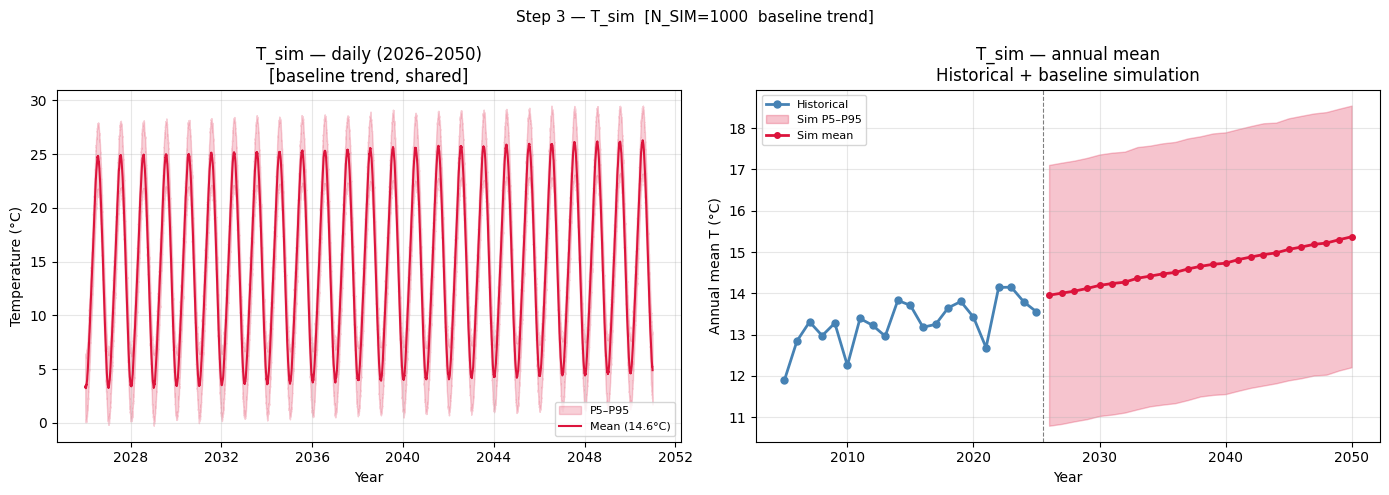

In [13]:
print(f"\n── Step 3: Reconstruct T_sim(t) [shared] ────────────────────────")
 
T_sim = np.zeros((N_SIM, N_DAYS))
 
for sim_id in range(N_SIM):
    resid_prev = temp_ar_init.copy()
    for t in range(N_DAYS):
        innovation = eps_temp_raw[sim_id, t]
        resid_t    = (ar_temp[0] * resid_prev[0]
                    + ar_temp[1] * resid_prev[1]
                    + innovation)
        T_sim[sim_id, t] = temp_seasonal_sim[t] + resid_t
        resid_prev = np.array([resid_t, resid_prev[0]])
    if (sim_id + 1) % 200 == 0:
        print(f"  T_sim: {sim_id+1}/{N_SIM}")
 
T_flat = T_sim.ravel()
print(f"\n  T_sim stats:")
print(f"    mean={T_flat.mean():.2f}°C  std={T_flat.std():.2f}°C  "
      f"p5={np.percentile(T_flat,5):.1f}°C  p95={np.percentile(T_flat,95):.1f}°C")
for yr in [2026, 2035, 2050]:
    m = (df_cal["year"] == yr).values
    print(f"    {yr} mean: {T_sim[:,m].mean():.2f}°C  "
          f"{'✓' if 10 < T_sim[:,m].mean() < 22 else '✗'}")
 
# fan chart
T_mean = T_sim.mean(axis=0)
T_p5   = np.percentile(T_sim,  5, axis=0)
T_p95  = np.percentile(T_sim, 95, axis=0)
df_T_ann = pd.DataFrame({
    "year": df_cal["year"].values,
    "mean": T_mean, "p5": T_p5, "p95": T_p95
}).groupby("year")[["mean","p5","p95"]].mean()
 
temp_col_hist = next(
    (c for c in ["t2m_mean","t2m_daily","t2m","temp_mean","T_mean"]
     if c in df_temp_hist.columns), None
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.fill_between(dates_pd, T_p5, T_p95, alpha=0.20, color="crimson", label="P5–P95")
ax.plot(dates_pd, T_mean, color="crimson", lw=1.5, label=f"Mean ({T_mean.mean():.1f}°C)")
ax.set_xlabel("Year"); ax.set_ylabel("Temperature (°C)")
ax.set_title("T_sim — daily (2026–2050)\n[baseline trend, shared]")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
ax = axes[1]
if temp_col_hist:
    df_temp_hist["year_col"] = df_temp_hist["date"].dt.year
    T_hist_ann = df_temp_hist.groupby("year_col")[temp_col_hist].mean()
    ax.plot(T_hist_ann.index, T_hist_ann.values, "o-",
            color="steelblue", lw=2.0, ms=5, label="Historical")
ax.fill_between(df_T_ann.index, df_T_ann["p5"], df_T_ann["p95"],
                alpha=0.25, color="crimson", label="Sim P5–P95")
ax.plot(df_T_ann.index, df_T_ann["mean"], "o-",
        color="crimson", lw=2.0, ms=4, label="Sim mean")
ax.axvline(2025.5, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("Year"); ax.set_ylabel("Annual mean T (°C)")
ax.set_title("T_sim — annual mean\nHistorical + baseline simulation")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
plt.suptitle(f"Step 3 — T_sim  [N_SIM={N_SIM}  baseline trend]", fontsize=11)
plt.tight_layout()
plt.show()

# STEP 4 — Reconstruct GHI_sim(t) 

 [shared]

In [14]:
print(f"\n── Step 4: Reconstruct GHI_sim(t) [shared] ──────────────────────")
 
def invert_logit_to_kt(Y_t, alpha, beta):
    Xp = 1.0 / (1.0 + np.exp(-Y_t))
    Xt = alpha + beta * Xp
    return float(np.clip(1.0 - Xt, 0.001, 0.999))
 
KT_sim  = np.zeros((N_SIM, N_DAYS))
GHI_sim = np.zeros((N_SIM, N_DAYS))
 
for sim_id in range(N_SIM):
    ytilde_prev = kt_ytilde_init.copy()
    eps_prev    = kt_eps_init
    for t in range(N_DAYS):
        eps_t    = eps_kt_raw[sim_id, t]
        ytilde_t = (arma_phi[0]   * ytilde_prev[0]
                  + arma_phi[1]   * ytilde_prev[1]
                  + eps_t + arma_theta[0] * eps_prev)
        Y_t  = ytilde_t + Y_bar_sim[t]
        kt_t = invert_logit_to_kt(Y_t, alpha_kt, beta_kt)
        KT_sim[sim_id, t]  = kt_t
        GHI_sim[sim_id, t] = kt_t * ghi_clearsky_sim[t]
        ytilde_prev = np.array([ytilde_t, ytilde_prev[0]])
        eps_prev    = eps_t
    if (sim_id + 1) % 200 == 0:
        print(f"  GHI_sim: {sim_id+1}/{N_SIM}")
 
KT_flat  = KT_sim.ravel()
GHI_flat = GHI_sim.ravel()
print(f"  KT_sim : mean={KT_flat.mean():.4f}  "
      f"p5={np.percentile(KT_flat,5):.4f}  p95={np.percentile(KT_flat,95):.4f}")
print(f"  GHI_sim: mean={GHI_flat.mean():.0f}  "
      f"p5={np.percentile(GHI_flat,5):.0f}  p95={np.percentile(GHI_flat,95):.0f} Wh/m2")


── Step 4: Reconstruct GHI_sim(t) [shared] ──────────────────────
  GHI_sim: 200/1000
  GHI_sim: 400/1000
  GHI_sim: 600/1000
  GHI_sim: 800/1000
  GHI_sim: 1000/1000
  KT_sim : mean=0.7684  p5=0.1736  p95=0.9990
  GHI_sim: mean=4128  p5=603  p95=8009 Wh/m2


# STEP 5 — Reconstruct CR_sim(t)  

[one per penetration scenario]


── Step 5: Reconstruct CR_sim(t) [per penetration scenario] ─────

  Processing: Current Trend (30%)
    done (1000 paths × 9131 days)
    mean=0.7574  std=0.7067  p5=-0.3792  p95=1.8542
    μ_CR(2050)=0.6511  CR_sim(2050) mean=0.6496

  Processing: PNIEC 2024 (45%)
    done (1000 paths × 9131 days)
    mean=0.6799  std=0.7103  p5=-0.4625  p95=1.7817
    μ_CR(2050)=0.5811  CR_sim(2050) mean=0.5796

  Processing: ENTSO-E DE (60%)
    done (1000 paths × 9131 days)
    mean=0.6528  std=0.7102  p5=-0.4893  p95=1.7542
    μ_CR(2050)=0.5728  CR_sim(2050) mean=0.5713


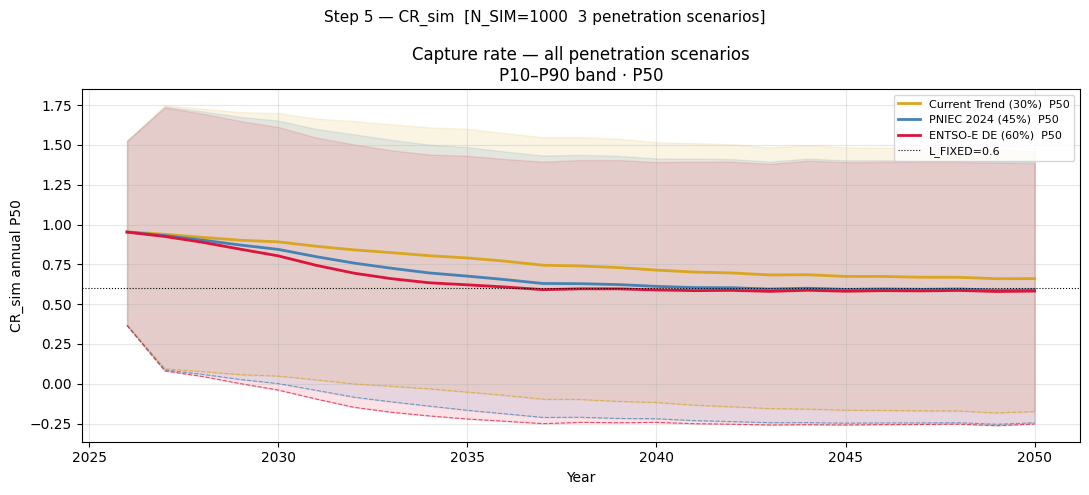

In [15]:
print(f"\n── Step 5: Reconstruct CR_sim(t) [per penetration scenario] ─────")
 
CR_sim_scenarios = {}
colors_scen = {
    "current_trend": "goldenrod",
    "pniec":         "steelblue",
    "entso_e":       "crimson",
}
years_unique = sorted(df_cal["year"].unique())
 
for scen_key, mu_CR_arr in mu_CR_scenarios.items():
    label = PEN_LABELS[scen_key]
    print(f"\n  Processing: {label}")
    CR_sim_scen = np.zeros((N_SIM, N_DAYS))
    # Vectorised over all N_SIM paths simultaneously
    cr_buf   = np.tile(cr_resid_init, (N_SIM, 1))  # (N_SIM, 8)
    u_buf    = np.tile(u_s_init,      (N_SIM, 1))  # (N_SIM, 7)
    sig2_vec = np.full(N_SIM, sigma2_init)
    for t in range(N_DAYS):
        sig2_t = (omega_g / 1e4) + alpha_g * u_buf[:, -1]**2 + beta_g * sig2_vec
        sig2_t = np.minimum(sig2_t, 0.25)  # cap at sigma=0.5 to prevent GARCH explosion
        u_t    = eps_cr_raw[:, t] * np.sqrt(sig2_t)
        cr_t   = (  phi_s   * cr_buf[:, -1]
                  + Phi_s   * cr_buf[:, -7]
                  - phi_s * Phi_s * cr_buf[:, -8]
                  + theta_q * u_buf[:, -7]
                  + u_t)
        CR_sim_scen[:, t] = mu_CR_arr[t] + cr_t
        cr_buf[:, :-1] = cr_buf[:, 1:]; cr_buf[:, -1] = cr_t
        u_buf[:, :-1]  = u_buf[:, 1:];  u_buf[:, -1]  = u_t
        sig2_vec = sig2_t
    print(f"    done ({N_SIM} paths × {N_DAYS} days)")
    CR_sim_scenarios[scen_key] = CR_sim_scen
    CR_flat_s = CR_sim_scen.ravel()
    mu50      = float(mu_CR_arr[df_cal["year"] == 2050].mean())
    cr50_mean = float(CR_sim_scen[:, df_cal["year"].values == 2050].mean())
    print(f"    mean={CR_flat_s.mean():.4f}  std={CR_flat_s.std():.4f}  "
          f"p5={np.percentile(CR_flat_s,5):.4f}  p95={np.percentile(CR_flat_s,95):.4f}")
    print(f"    μ_CR(2050)={mu50:.4f}  CR_sim(2050) mean={cr50_mean:.4f}")
 
# comparison plot
fig, ax = plt.subplots(figsize=(11, 5))
for scen_key, CR_sim_scen in CR_sim_scenarios.items():
    p10_yr = [np.percentile(CR_sim_scen[:, df_cal["year"].values==yr], 10)
               for yr in years_unique]
    p50_yr = [np.percentile(CR_sim_scen[:, df_cal["year"].values==yr], 50)
               for yr in years_unique]
    p90_yr = [np.percentile(CR_sim_scen[:, df_cal["year"].values==yr], 90)
               for yr in years_unique]
    color = colors_scen[scen_key]
    ax.fill_between(years_unique, p10_yr, p90_yr, alpha=0.12, color=color)
    ax.plot(years_unique, p50_yr, color=color, lw=2.0,
            label=f"{PEN_LABELS[scen_key]}  P50")
    ax.plot(years_unique, p10_yr, color=color, lw=0.8, ls="--", alpha=0.7)
ax.axhline(L_FIXED, color="black", lw=0.8, ls=":", label=f"L_FIXED={L_FIXED}")
ax.set_xlabel("Year"); ax.set_ylabel("CR_sim annual P50")
ax.set_title("Capture rate — all penetration scenarios\nP10–P90 band · P50")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle(f"Step 5 — CR_sim  [N_SIM={N_SIM}  3 penetration scenarios]", fontsize=11)
plt.tight_layout()
plt.show()
 

# STEP 6 — Save one parquet per penetration scenario

In [16]:
print(f"\n── Step 6: Save physical variables ─────────────────────────────")
 
dates_rep = np.tile(dates_sim, N_SIM)
sim_ids   = np.repeat(np.arange(N_SIM), N_DAYS)
cal_cols  = df_cal[["date","year","month","doy","ghi_clearsky"]].copy()
cal_cols["date"] = pd.to_datetime(cal_cols["date"])
 
saved_files = []
 
for scen_key, CR_sim_scen in CR_sim_scenarios.items():
    label    = PEN_LABELS[scen_key]
    pen_arr  = pen_arrays[scen_key]
    mu_arr   = mu_CR_scenarios[scen_key]
    out_file = output_path / f"mc_physical_variables_{scen_key}.parquet"
 
    df_physical = pd.DataFrame({
        "sim_id":  sim_ids.astype(np.int32),
        "date":    dates_rep,
        "T_sim":   T_sim.ravel().astype(np.float32),
        "GHI_sim": GHI_sim.ravel().astype(np.float32),
        "KT_sim":  KT_sim.ravel().astype(np.float32),
        "CR_sim":  CR_sim_scen.ravel().astype(np.float32),
    })
    df_physical["date"] = pd.to_datetime(df_physical["date"])
    df_physical = df_physical.merge(cal_cols, on="date", how="left")
    df_physical["pen_scenario"]      = np.tile(pen_arr.astype(np.float32), N_SIM)
    df_physical["mu_CR_sim"]         = np.tile(mu_arr.astype(np.float32), N_SIM)
    df_physical["pen_scenario_name"] = scen_key
 
    df_physical.to_parquet(out_file, index=False, compression="snappy")
    file_mb = out_file.stat().st_size / 1e6
    saved_files.append(str(out_file))
 
    print(f"  [{scen_key}] {label}")
    print(f"    File : {out_file.name}  ({file_mb:.1f} MB)")
    print(f"    Rows : {len(df_physical):,}")
    print(f"    CR_sim mean : {df_physical['CR_sim'].mean():.4f}")
    print(f"    T_sim  mean : {df_physical['T_sim'].mean():.2f}°C")
    print(f"    GHI_sim mean: {df_physical['GHI_sim'].mean():.0f} Wh/m2")
 
print(f"\n── Reconstruction complete ───────────────────────────────────────")
print(f"  Saved {len(saved_files)} parquet files:")
for f in saved_files:
    print(f"    {Path(f).name}")
print(f"\n  T_sim and GHI_sim are SHARED across all penetration scenarios.")
print(f"  CR_sim differs per scenario due to μ_CR(pen_scenario).")



── Step 6: Save physical variables ─────────────────────────────
  [current_trend] Current Trend (30%)
    File : mc_physical_variables_current_trend.parquet  (220.3 MB)
    Rows : 9,131,000
    CR_sim mean : 0.7574
    T_sim  mean : 14.65°C
    GHI_sim mean: 4128 Wh/m2
  [pniec] PNIEC 2024 (45%)
    File : mc_physical_variables_pniec.parquet  (220.3 MB)
    Rows : 9,131,000
    CR_sim mean : 0.6799
    T_sim  mean : 14.65°C
    GHI_sim mean: 4128 Wh/m2
  [entso_e] ENTSO-E DE (60%)
    File : mc_physical_variables_entso_e.parquet  (220.3 MB)
    Rows : 9,131,000
    CR_sim mean : 0.6528
    T_sim  mean : 14.65°C
    GHI_sim mean: 4128 Wh/m2

── Reconstruction complete ───────────────────────────────────────
  Saved 3 parquet files:
    mc_physical_variables_current_trend.parquet
    mc_physical_variables_pniec.parquet
    mc_physical_variables_entso_e.parquet

  T_sim and GHI_sim are SHARED across all penetration scenarios.
  CR_sim differs per scenario due to μ_CR(pen_scenario).


# STEP 7 — Historical modelled variables reconstruction (2005–2025)

In [17]:
print(f"\n── Step 7: Historical modelled reconstruction (2005–2025) ────────")

T_STC = 25.0   # standard test condition temperature

# --- NOCT uplift (same pkl as Revenue Index notebook) -----------------------
with open(models_path / "Temperature" / "noct_uplift_params.pkl", "rb") as f:
    _noct = pickle.load(f)
_uplift_by_doy = _noct["uplift_by_doy"]
_uplift_mean   = float(np.mean(list(_uplift_by_doy.values())))

# --- merge historical CR and temperature data --------------------------------
_df_h = df_cr_hist[["date", "year", "capture_rate", "CR_seasonal_full", "CR_resid", "u_s"]].copy()
_df_h = _df_h.merge(
    df_solar_hist[["date", "GHI_obs", "GHI_cs"]].rename(
        columns={"GHI_obs": "ghi_sum", "GHI_cs": "ghi_cs_sum"}),
    on="date", how="left"
).merge(
    df_temp_hist[["date", "t2m_mean", "fourier_fit", "ar1_resid"]],
    on="date", how="inner"
).sort_values("date").reset_index(drop=True)

# --- GHI_modelled: ARMA fitted values -> inverse logit -> Kt -> GHI ----------
_doy   = _df_h["date"].dt.dayofyear.values
_t_rad = 2.0 * np.pi * _doy / 365.0
_Y_bar = (a_seasonal[0]
          + a_seasonal[1] * np.cos(_t_rad)
          + a_seasonal[2] * np.sin(_t_rad))

_fv = pd.Series(
    arma_result.fittedvalues.values,
    index=pd.to_datetime(arma_result.fittedvalues.index),
    name="Ytilde_fitted"
)
_df_h = _df_h.merge(_fv.rename_axis("date").reset_index(), on="date", how="left")

_Yt     = _df_h["Ytilde_fitted"].values + _Y_bar
_Xp     = 1.0 / (1.0 + np.exp(-_Yt))
_Kt_fit = np.clip(1.0 - (alpha_kt + beta_kt * _Xp), 0.0, 1.0)

_df_h["GHI_actual"]   = _df_h["ghi_sum"].values
_df_h["GHI_modelled"] = _Kt_fit * _df_h["ghi_cs_sum"].values

# --- T_modelled: Fourier deterministic fit (fourier_fit = seasonal + trend) --
_df_h["T_actual"]   = _df_h["t2m_mean"].values
_df_h["T_modelled"] = _df_h["fourier_fit"].values

# --- CR_modelled: seasonal mean + SARIMA fitted residuals --------------------
# SARIMA_fitted = CR_resid - u_s  (u_s = SARIMA innovations)
# Matches the in-sample reconstruction in Capture Price Model notebook
_df_h["CR_actual"]   = _df_h["capture_rate"].values
_df_h["CR_modelled"] = (
    _df_h["CR_seasonal_full"] + _df_h["CR_resid"].fillna(0) - _df_h["u_s"].fillna(0)
).values

# --- P and RI (actual and modelled) ------------------------------------------
def _compute_P(ghi, t2m, doy_arr):
    _upl = np.array([_uplift_by_doy.get(int(d), _uplift_mean) for d in doy_arr])
    return (ghi / G_STC) * (1.0 + GAMMA * (t2m + _upl - T_STC)) * PR

_df_h["P_actual"]   = _compute_P(_df_h["GHI_actual"].values,
                                  _df_h["T_actual"].values, _doy)
_df_h["P_modelled"] = _compute_P(_df_h["GHI_modelled"].values,
                                  _df_h["T_modelled"].values, _doy)

_df_h["RI_actual"]   = _df_h["P_actual"].values   * _df_h["CR_actual"].values
_df_h["RI_modelled"] = _df_h["P_modelled"].values * _df_h["CR_modelled"].values

# --- output dataframe --------------------------------------------------------
df_hist_reconstructed = _df_h[[
    "date", "year",
    "GHI_actual", "GHI_modelled",
    "T_actual",   "T_modelled",
    "CR_actual",  "CR_modelled",
    "P_actual",   "P_modelled",
    "RI_actual",  "RI_modelled",
]].copy()

# --- summary -----------------------------------------------------------------
_yr0, _yr1 = int(df_hist_reconstructed["year"].min()), int(df_hist_reconstructed["year"].max())
print(f"  df_hist_reconstructed: {len(df_hist_reconstructed):,} rows  ({_yr0}–{_yr1})")
print()
print(f"  {'Var':<5}  {'Mean actual':>13}  {'Mean modelled':>13}  {'Corr':>7}  {'NaN mod':>8}")
print(f"  {'-'*5}  {'-'*13}  {'-'*13}  {'-'*7}  {'-'*8}")
for _tag, _ca, _cm in [("GHI","GHI_actual","GHI_modelled"),
                        ("T",  "T_actual",  "T_modelled"),
                        ("CR", "CR_actual", "CR_modelled"),
                        ("P",  "P_actual",  "P_modelled"),
                        ("RI", "RI_actual", "RI_modelled")]:
    _a  = df_hist_reconstructed[_ca].values
    _m  = df_hist_reconstructed[_cm].values
    _ok = np.isfinite(_a) & np.isfinite(_m)
    _c  = float(np.corrcoef(_a[_ok], _m[_ok])[0, 1]) if _ok.sum() > 2 else np.nan
    _nn = int((~np.isfinite(_m)).sum())
    print(f"  {_tag:<5}  {np.nanmean(_a):>13.4f}  {np.nanmean(_m):>13.4f}  "
          f"{_c:>7.4f}  {_nn:>8d}")


── Step 7: Historical modelled reconstruction (2005–2025) ────────
  df_hist_reconstructed: 7,670 rows  (2005–2025)

  Var      Mean actual  Mean modelled     Corr   NaN mod
  -----  -------------  -------------  -------  --------
  GHI        4085.1976      4578.6350   0.8790         0
  T            13.2999        13.2999   0.9442         0
  CR            1.0012         1.0012   0.8183         0
  P             3.1399         3.5258   0.8654         0
  RI            3.1632         3.5578   0.8731         0


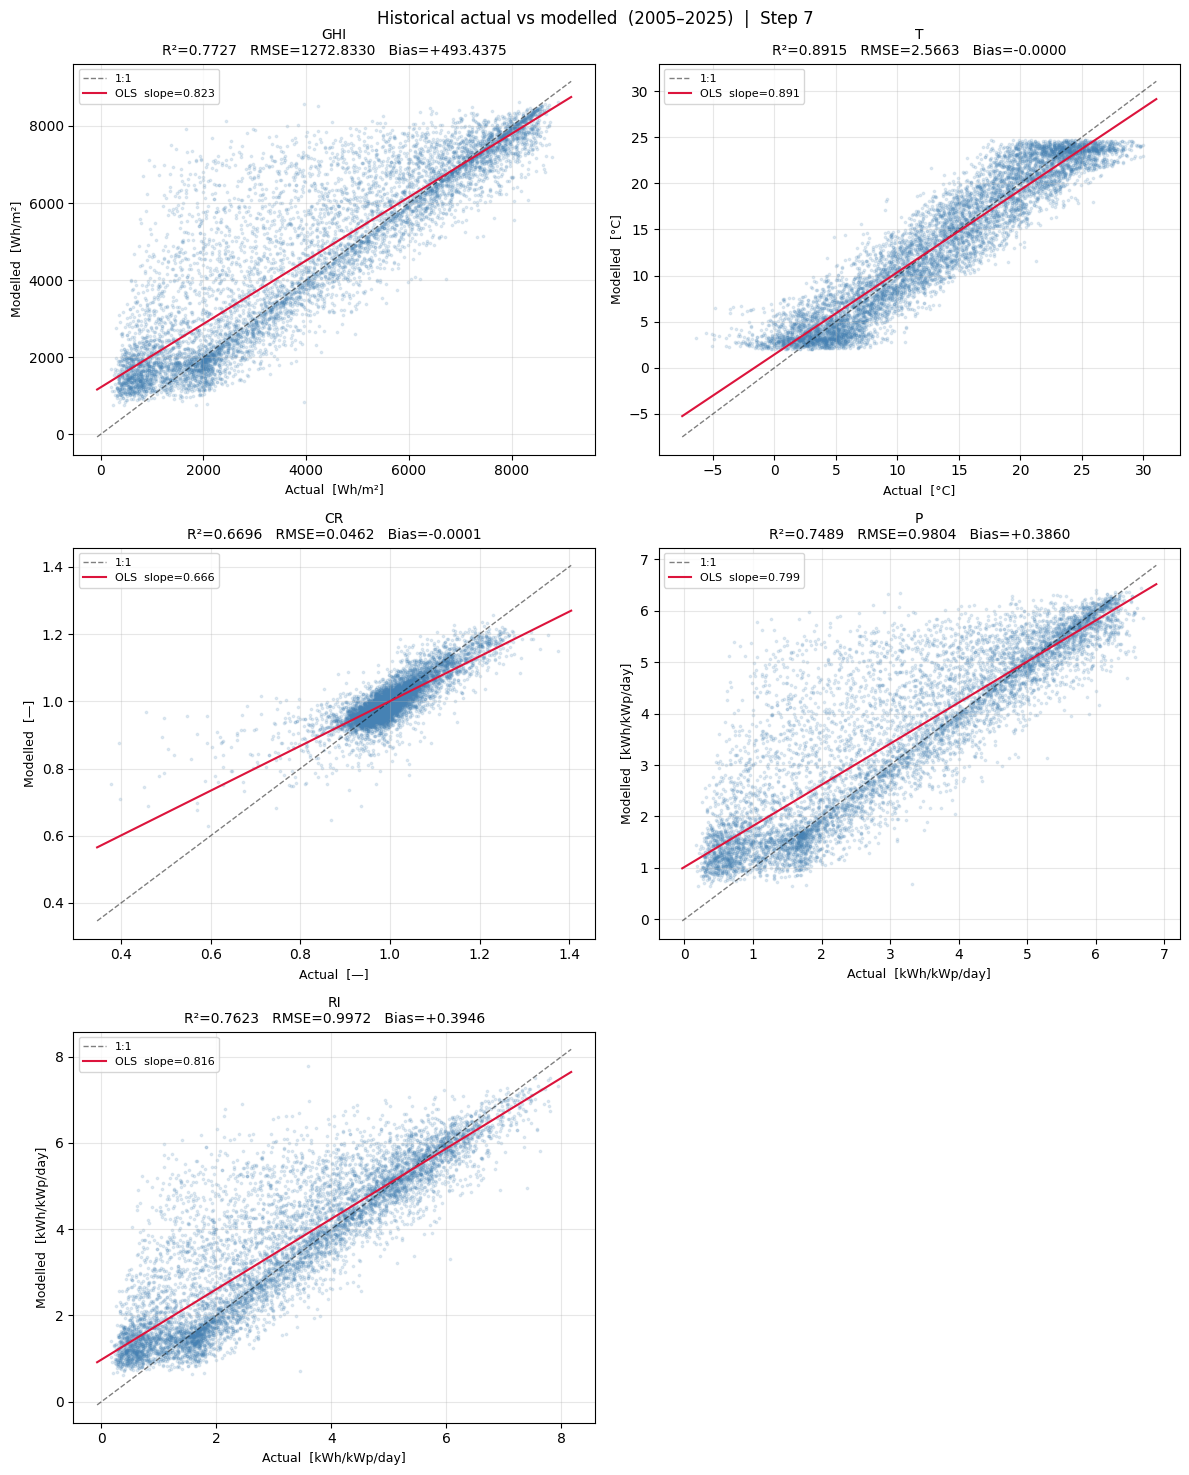

In [18]:
from scipy import stats

# =============================================================================
# Step 7 — Scatter: actual vs modelled (2005–2025)
# =============================================================================
_vars = [
    ("GHI", "GHI_actual", "GHI_modelled", "Wh/m²"),
    ("T",   "T_actual",   "T_modelled",   "°C"),
    ("CR",  "CR_actual",  "CR_modelled",  "—"),
    ("P",   "P_actual",   "P_modelled",   "kWh/kWp/day"),
    ("RI",  "RI_actual",  "RI_modelled",  "kWh/kWp/day"),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes_flat = axes.flatten()

for ax, (tag, ca, cm, unit) in zip(axes_flat, _vars):
    _a = df_hist_reconstructed[ca].values
    _m = df_hist_reconstructed[cm].values
    _ok = np.isfinite(_a) & np.isfinite(_m)
    x, y = _a[_ok], _m[_ok]

    sl, ic, r, *_ = stats.linregress(x, y)
    r2   = float(r ** 2)
    rmse = float(np.sqrt(np.mean((y - x) ** 2)))
    bias = float(np.mean(y - x))

    _pad = (x.max() - x.min()) * 0.03
    _xl  = np.array([x.min() - _pad, x.max() + _pad])

    ax.scatter(x, y, s=3, alpha=0.15, color="steelblue", rasterized=True)
    ax.plot(_xl, _xl,           "k--", lw=1.0, alpha=0.5, label="1:1")
    ax.plot(_xl, ic + sl * _xl, color="crimson", lw=1.5,
            label=f"OLS  slope={sl:.3f}")
    ax.set_xlabel(f"Actual  [{unit}]", fontsize=9)
    ax.set_ylabel(f"Modelled  [{unit}]", fontsize=9)
    ax.set_title(
        f"{tag}\nR²={r2:.4f}   RMSE={rmse:.4f}   Bias={bias:+.4f}",
        fontsize=10
    )
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes_flat[-1].set_visible(False)  # hide unused 6th panel

fig.suptitle("Historical actual vs modelled  (2005–2025)  |  Step 7", fontsize=12)
fig.tight_layout()
plt.show()

  Period : 2015–2025  (n=4,018 days)

  Var     KS stat    p-value        P5     P10     P25     P50     P75     P90     P95   (mod - act)
  -----  --------  ---------  ------  ------  ------  ------  ------  ------  ------
  GHI      0.1110     0.0000  +692.638  +666.816  +295.218  +797.444  +454.742  -5.083  -141.434
  T        0.0791     0.0000  +0.831  +0.046  -0.200  +0.076  +0.200  -0.406  -1.513
  CR       0.0886     0.0000  +0.019  +0.008  -0.000  -0.005  -0.008  -0.007  -0.011
  P        0.1157     0.0000  +0.595  +0.550  +0.239  +0.621  +0.309  -0.013  -0.078
  RI       0.1150     0.0000  +0.563  +0.533  +0.221  +0.604  +0.325  +0.101  -0.027


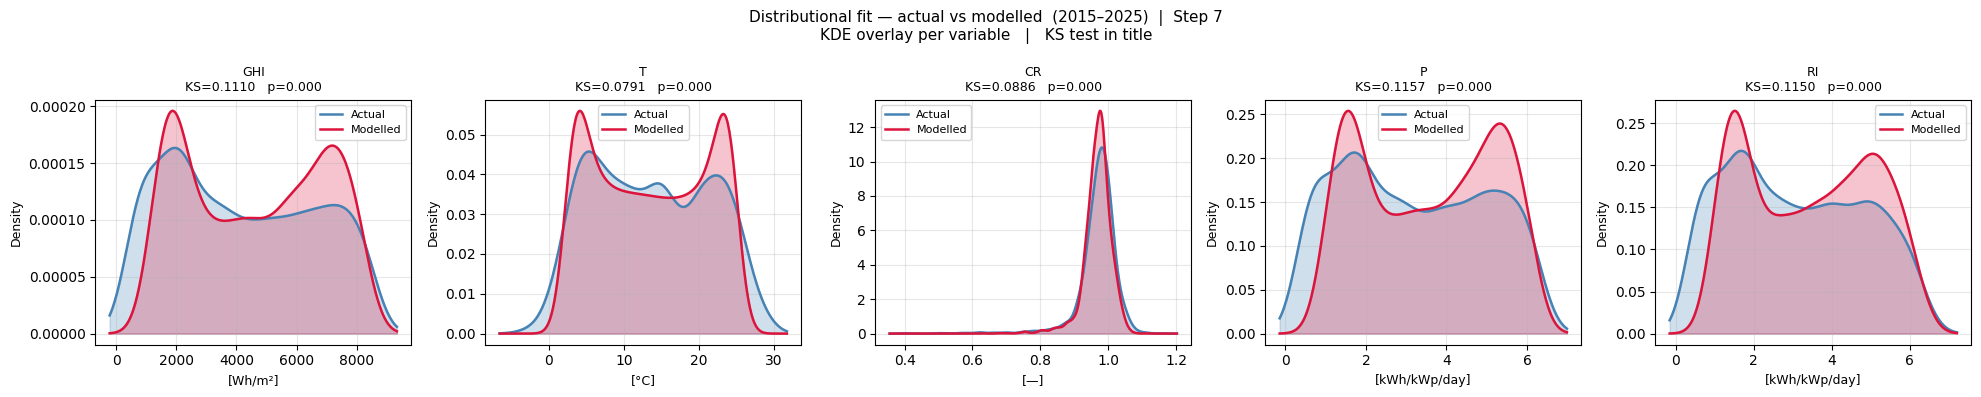


                   P5      P10      P25      P50      P75      P90      P95
  GHI act     707.719  989.653  2000.057  3876.176  6317.552  7639.922  8088.896
  GHI mod     1400.357  1656.469  2295.275  4673.620  6772.294  7634.839  7947.463
  GHI diff    +692.638  +666.816  +295.218  +797.444  +454.742   -5.083  -141.434

  T act         2.281    3.533    6.742   13.396   20.490   24.149   25.719
  T mod         3.111    3.579    6.542   13.472   20.690   23.742   24.206
  T diff       +0.831   +0.046   -0.200   +0.076   +0.200   -0.406   -1.513

  CR act        0.884    0.920    0.951    0.977    1.000    1.021    1.037
  CR mod        0.903    0.928    0.951    0.972    0.992    1.014    1.026
  CR diff      +0.019   +0.008   -0.000   -0.005   -0.008   -0.007   -0.011

  P act         0.578    0.827    1.654    3.035    4.779    5.685    5.993
  P mod         1.173    1.377    1.893    3.656    5.088    5.672    5.915
  P diff       +0.595   +0.550   +0.239   +0.621   +0.309   -0.013

In [19]:
from scipy import stats
from scipy.stats import ks_2samp, gaussian_kde

# =============================================================================
# Step 7 — Distributional fit: actual vs modelled (2015–2025)
# KDE overlay + percentile calibration + KS test per variable
# =============================================================================
DIST_START = 2015

_df_dist = df_hist_reconstructed[df_hist_reconstructed["year"] >= DIST_START].copy()

_vars = [
    ("GHI", "GHI_actual", "GHI_modelled", "Wh/m²"),
    ("T",   "T_actual",   "T_modelled",   "°C"),
    ("CR",  "CR_actual",  "CR_modelled",  "—"),
    ("P",   "P_actual",   "P_modelled",   "kWh/kWp/day"),
    ("RI",  "RI_actual",  "RI_modelled",  "kWh/kWp/day"),
]
_pcts = [5, 10, 25, 50, 75, 90, 95]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

print(f"  Period : {DIST_START}–2025  (n={len(_df_dist):,} days)")
print()
print(f"  {'Var':<5}  {'KS stat':>8}  {'p-value':>9}  "
      + "".join(f"  {'P'+str(p):>6}" for p in _pcts) + "   (mod - act)")
print(f"  {'-'*5}  {'-'*8}  {'-'*9}  " + "  ".join(["-"*6] * len(_pcts)))

for ax, (tag, ca, cm, unit) in zip(axes, _vars):
    _a = _df_dist[ca].values
    _m = _df_dist[cm].values
    _ok = np.isfinite(_a) & np.isfinite(_m)
    x, y = _a[_ok], _m[_ok]

    _lo  = min(x.min(), y.min())
    _hi  = max(x.max(), y.max())
    _pad = (_hi - _lo) * 0.05
    x_grid = np.linspace(_lo - _pad, _hi + _pad, 400)

    kde_a = gaussian_kde(x)
    kde_m = gaussian_kde(y)

    ax.fill_between(x_grid, kde_a(x_grid), alpha=0.25, color="steelblue")
    ax.fill_between(x_grid, kde_m(x_grid), alpha=0.25, color="crimson")
    ax.plot(x_grid, kde_a(x_grid), color="steelblue", lw=1.8, label="Actual")
    ax.plot(x_grid, kde_m(x_grid), color="crimson",   lw=1.8, label="Modelled")

    ks_stat, ks_p = ks_2samp(x, y)

    ax.set_xlabel(f"[{unit}]", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.set_title(f"{tag}\nKS={ks_stat:.4f}   p={ks_p:.3f}", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    q_a = np.percentile(x, _pcts)
    q_m = np.percentile(y, _pcts)
    diff_str = "  ".join(f"{(q_m[i] - q_a[i]):>+6.3f}" for i in range(len(_pcts)))
    print(f"  {tag:<5}  {ks_stat:>8.4f}  {ks_p:>9.4f}  {diff_str}")

fig.suptitle(
    f"Distributional fit — actual vs modelled  ({DIST_START}–2025)  |  Step 7\n"
    "KDE overlay per variable   |   KS test in title",
    fontsize=11
)
fig.tight_layout()
plt.show()

# --- percentile calibration table -------------------------------------------
print()
print(f"  {'':10}" + "".join(f"  {'P'+str(p):>7}" for p in _pcts))
for tag, ca, cm, unit in _vars:
    x = _df_dist[ca].dropna().values
    y = _df_dist[cm].dropna().values
    q_a = np.percentile(x, _pcts)
    q_m = np.percentile(y, _pcts)
    print(f"  {tag+' act':<10}" + "".join(f"  {v:>7.3f}" for v in q_a))
    print(f"  {tag+' mod':<10}" + "".join(f"  {v:>7.3f}" for v in q_m))
    print(f"  {tag+' diff':<10}" + "".join(f"  {(q_m[i]-q_a[i]):>+7.3f}" for i in range(len(_pcts))))
    print()